bold text#  Production-Grade Agentic RAG — Advanced Multi-Source Pipeline
> **Corrective + Self-Reflective RAG** with adaptive retrieval, semantic grading,  
> iterative query rewriting, hallucination detection, answer validation,  
> persistent vectorstore, streaming, full error handling, and LangSmith observability.

---
## Architecture
```
User Question
      │
      ▼
┌─────────────────────────────────────────────────────────────────┐
│                    Agentic RAG Graph                            │
│  ┌─────────┐   tool_calls?  ┌──────────────────┐               │
│  │  Agent  │─────────────►  │ ToolNode         │               │
│  │  (LLM)  │◄─────────────  │ (LangGraph +     │               │
│  └────┬────┘  tool results  │  LangChain RAG)  │               │
│       │                     └──────────────────┘               │
│       ▼                                                         │
│  ┌──────────────┐   relevant?  ┌──────────────┐                │
│  │ Grade Docs   │─── yes ────► │   Generate   │──► END         │
│  └──────┬───────┘              └──────┬───────┘                │
│         │ no                          │ hallucination check     │
│         ▼                             ▼                         │
│  ┌──────────────┐              ┌──────────────┐                │
│  │   Rewrite    │              │  Validate    │──► END         │
│  │   Query      │              │  Answer      │                │
│  └──────┬───────┘              └──────────────┘                │
│         └──────────────────────────────────────────► agent     │
└─────────────────────────────────────────────────────────────────┘
         │
         ▼
  MemorySaver (in-memory) + SQLite (persistent)
```

###  All ~92 issues fixed in this version


##  1. Install Dependencies

In [25]:
# Run once — safe to re-run
%pip install -q \
    langchain langchain-community langchain-groq \
    langchain-huggingface sentence-transformers \
    langgraph langgraph-checkpoint-sqlite \
    faiss-cpu python-dotenv pydantic rich \
    beautifulsoup4 lxml requests


##  2. Imports & Configuration

In [26]:
from __future__ import annotations

import os, re, time, json, logging, sqlite3, hashlib, traceback, warnings
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Literal, Optional, Sequence, Tuple
from typing_extensions import Annotated, TypedDict

# LangChain core
from langchain_core.messages import (
    AIMessage, BaseMessage, HumanMessage, SystemMessage, ToolMessage
)
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableConfig
from langchain_core.documents import Document

# FIX #1: correct import path for create_retriever_tool
try:
    from langchain_core.tools import create_retriever_tool
except ImportError:
    from langchain.tools.retriever import create_retriever_tool  # legacy fallback

# LangChain community
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Embeddings (free, no API key)
from langchain_huggingface import HuggingFaceEmbeddings

# LLM
from langchain_groq import ChatGroq

# Pydantic
from pydantic import BaseModel, Field

# LangGraph
from langgraph.graph import END, StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langgraph.checkpoint.sqlite import SqliteSaver

# Display
from IPython.display import Image, display, Markdown
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
os.environ["USER_AGENT"] = "AgenticRAG/2.0 (production-notebook)"

# FIX #2: Set up logger BEFORE any code that uses it
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("agentic_rag")

print(" Imports successful")
print(f" Logger ready: {logger.name}")


 Imports successful
 Logger ready: agentic_rag


In [27]:
# FIX #4 / API Key Security: Load from .env — never hardcode in production.
# Create a .env file in the same directory with: GROQ_API_KEY=gsk_...
load_dotenv()


if not os.getenv("GROQ_API_KEY"):
    raise EnvironmentError(
        "GROQ_API_KEY not set.\n"
        "Options:\n"
        "  1. Add GROQ_API_KEY=gsk_... to a .env file next to this notebook.\n"
        "  2. Uncomment the os.environ line above and paste your key.\n"
        "  3. Set it as a Colab/Jupyter secret.\n"
        "Get a free key at https://console.groq.com"
    )

CONFIG = {
    # LLM
    "model":             "llama-3.3-70b-versatile",
    # FIX #23: fallback model uses a smaller/different quota pool
    "fallback_model":    "meta-llama/llama-4-scout-17b-16e-instruct",
    "temperature":       0.0,
    "max_tokens":        1024,   # FIX #28: reduced to conserve tokens
    "request_timeout":   45,

    # Retrieval
    "chunk_size":        800,
    "chunk_overlap":     150,
    "top_k":             3,      # FIX #28: smaller k = smaller prompts
    "embedding_model":   "all-MiniLM-L6-v2",

    # Graph
    "max_rewrites":      2,      # FIX #16/#17: hard cap; >= used everywhere
    "db_path":           "agentic_rag_memory.db",
    "vectorstore_dir":   "vectorstore_cache",

    # Retry / rate-limit
    "retry_base_delay":  2.0,    # FIX #20: exponential back-off base (seconds)
    "max_retries":       3,

    # Observability
    "langchain_project": "AgenticRAG_Production",
}

print(" Config loaded")
print(f"   Primary model : {CONFIG['model']}")
print(f"   Fallback model: {CONFIG['fallback_model']}")
print(f"   Max tokens    : {CONFIG['max_tokens']}")
print(f"   Max rewrites  : {CONFIG['max_rewrites']}")


 Config loaded
   Primary model : llama-3.3-70b-versatile
   Fallback model: meta-llama/llama-4-scout-17b-16e-instruct
   Max tokens    : 1024
   Max rewrites  : 2


##  3. Embeddings — Free Local Model (No OpenAI Key Needed)

In [28]:
print("⏳ Loading embedding model (downloads once, cached locally)…")
embeddings = HuggingFaceEmbeddings(
    model_name=CONFIG["embedding_model"],
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)
_test_vec = embeddings.embed_query("test")
assert len(_test_vec) == 384, f"Unexpected embedding dim: {len(_test_vec)}"
print(f"✅ Embeddings ready: {CONFIG['embedding_model']}")
print(f"   Embedding dimension: {len(_test_vec)}")


⏳ Loading embedding model (downloads once, cached locally)…


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embeddings ready: all-MiniLM-L6-v2
   Embedding dimension: 384


##  4. Document Loader — Robust with Redirect Detection

In [29]:
def load_urls_robust(urls: List[str], source_tag: str) -> List[Document]:
    """
    FIX #7/#8/#9: Load URLs, filter redirect/empty pages, deduplicate.
    Falls back to requests+BS4 if WebBaseLoader returns short/redirect content.
    """
    import requests
    from bs4 import BeautifulSoup

    all_docs: List[Document] = []
    seen_hashes: set = set()

    for url in urls:
        try:
            print(f"    Loading: {url}")
            # --- Primary: WebBaseLoader ---
            loader = WebBaseLoader(web_paths=(url,))
            raw_docs = loader.load()

            # --- Validate content quality ---
            valid = []
            for d in raw_docs:
                text = d.page_content.strip()
                if len(text) < 200:
                    print(f"        WebBaseLoader too short ({len(text)} chars) — trying fallback")
                    valid = []  # trigger fallback
                    break
                if text.lower().startswith("redirecting") or "just a moment" in text.lower():
                    print(f"        Redirect/bot-check detected — trying fallback")
                    valid = []
                    break
                valid.append(d)

            # --- Fallback: raw requests + BeautifulSoup ---
            if not valid:
                print(f"       Falling back to requests+BS4 for: {url}")
                try:
                    resp = requests.get(
                        url,
                        headers={"User-Agent": os.environ["USER_AGENT"]},
                        timeout=20,
                        allow_redirects=True,
                    )
                    resp.raise_for_status()
                    soup = BeautifulSoup(resp.text, "lxml")
                    # Remove nav/header/footer noise
                    for tag in soup(["nav", "header", "footer", "script", "style"]):
                        tag.decompose()
                    text = soup.get_text(separator="\n", strip=True)
                    if len(text) >= 200:
                        valid = [Document(
                            page_content=text,
                            metadata={"source": url, "source_tag": source_tag},
                        )]
                        print(f"       Fallback succeeded ({len(text)} chars)")
                    else:
                        print(f"       Fallback also returned short content — skipping")
                except Exception as fe:
                    print(f"       Fallback failed: {fe}")

            # --- Dedup & append ---
            for d in valid:
                h = hashlib.md5(d.page_content[:500].encode()).hexdigest()
                if h not in seen_hashes:
                    seen_hashes.add(h)
                    d.metadata["source_tag"] = source_tag
                    all_docs.append(d)
                    print(f"       Added doc ({len(d.page_content)} chars)")

        except Exception as e:
            print(f"    Failed: {url}  →  {e}")

    print(f"\n    Total valid docs collected for '{source_tag}': {len(all_docs)}")
    if all_docs:
        print("\n    Preview (first 300 chars):")
        print(all_docs[0].page_content[:300])
    return all_docs


print(" load_urls_robust() defined")


 load_urls_robust() defined


## 5. Knowledge Sources — Working URLs with Fallback Text

In [30]:
# FIX #8/#29/#10: Updated to working URLs that serve real content.
# FIX #9/#31: Added fallback_text so every source has at least seed knowledge.
KNOWLEDGE_SOURCES = {
    "langgraph": {
        "urls": [
            "https://langchain-ai.github.io/langgraph/concepts/",
            "https://langchain-ai.github.io/langgraph/tutorials/introduction/",
            "https://langchain-ai.github.io/langgraph/how-tos/",
        ],
        "description": (
            "LangGraph documentation: stateful multi-actor graphs, nodes, edges, "
            "conditional routing, checkpointing, human-in-the-loop, and multi-agent workflows."
        ),
        "tool_name": "search_langgraph_docs",
        # FIX #31: Fallback seed text if all URLs fail
        "fallback_text": (
            "LangGraph is a library for building stateful, multi-actor applications with LLMs "
            "using graph-based control flow. Core concepts:\n"
            "- StateGraph: define a graph with a typed state schema.\n"
            "- Nodes: Python functions or runnables that transform state.\n"
            "- Edges: connections between nodes; can be conditional.\n"
            "- add_messages: reducer that appends messages to state.\n"
            "- MemorySaver / SqliteSaver: persistence backends for checkpointing.\n"
            "- interrupt(): pause execution for human approval.\n"
            "- Tools can be wrapped in ToolNode for automatic execution.\n"
            "- tools_condition: routing helper — goes to 'tools' if LLM called a tool, else END.\n"
            "- Compile with workflow.compile(checkpointer=checkpointer).\n"
            "- Invoke with graph.invoke(state, config={'configurable': {'thread_id': 'x'}}).\n"
            "- graph.stream() yields node-by-node updates.\n"
            "- get_state(config) retrieves thread snapshot.\n"
            "- Multi-agent: use subgraphs or pass state between separate graphs."
        ),
    },
    "langchain": {
        "urls": [
            "https://python.langchain.com/docs/tutorials/chatbot/",
            "https://python.langchain.com/docs/concepts/runnables/",
            "https://python.langchain.com/docs/concepts/retrievers/",
        ],
        "description": (
            "LangChain documentation: runnables, LCEL chains, retrievers, "
            "agents, chatbot construction, and memory."
        ),
        "tool_name": "search_langchain_docs",
        "fallback_text": (
            "LangChain is a framework for building LLM-powered applications.\n"
            "Core concepts:\n"
            "- Runnables: composable units with .invoke(), .batch(), .stream().\n"
            "- LCEL (LangChain Expression Language): pipe syntax (prompt | llm | parser).\n"
            "- Retrievers: fetch relevant documents (FAISS, Chroma, etc.).\n"
            "- ChatPromptTemplate: create multi-turn prompt templates.\n"
            "- StrOutputParser: parse LLM output to plain string.\n"
            "- Memory: ConversationBufferMemory, ConversationSummaryMemory.\n"
            "- Agents: LLMs that can choose and use tools dynamically.\n"
            "- WebBaseLoader: load web pages as Documents.\n"
            "- RecursiveCharacterTextSplitter: split docs into chunks.\n"
            "- FAISS.from_documents(): build in-memory vector index.\n"
            "- create_retriever_tool(): wrap a retriever as a tool for agents."
        ),
    },
}

print(" Knowledge sources configured")
for name, cfg in KNOWLEDGE_SOURCES.items():
    print(f"\n🔹 {name}  ({len(cfg['urls'])} URLs)")
    for url in cfg["urls"]:
        print(f"   • {url}")
print(f"\n Sources: {len(KNOWLEDGE_SOURCES)}  |  URLs: {sum(len(c['urls']) for c in KNOWLEDGE_SOURCES.values())}")


 Knowledge sources configured

🔹 langgraph  (3 URLs)
   • https://langchain-ai.github.io/langgraph/concepts/
   • https://langchain-ai.github.io/langgraph/tutorials/introduction/
   • https://langchain-ai.github.io/langgraph/how-tos/

🔹 langchain  (3 URLs)
   • https://python.langchain.com/docs/tutorials/chatbot/
   • https://python.langchain.com/docs/concepts/runnables/
   • https://python.langchain.com/docs/concepts/retrievers/

 Sources: 2  |  URLs: 6


##  6. VectorStore Factory — Disk Caching + Fallback Seed

In [31]:
import shutil

# Uncomment to force a full rebuild (e.g., after changing URLs):
# shutil.rmtree(CONFIG["vectorstore_dir"], ignore_errors=True)

vectorstores: Dict[str, FAISS] = {}

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CONFIG["chunk_size"],
    chunk_overlap=CONFIG["chunk_overlap"],
    add_start_index=True,
)

for source_name, source_cfg in KNOWLEDGE_SOURCES.items():
    cache_path = Path(CONFIG["vectorstore_dir"]) / source_name
    print(f"\n Processing source: {source_name!r}")

    # ── Load from cache if available ──────────────────────────────────────────
    if cache_path.exists():
        print(f"    Loading cached vectorstore from: {cache_path}")
        try:
            vectorstores[source_name] = FAISS.load_local(
                str(cache_path), embeddings, allow_dangerous_deserialization=True
            )
            print(f"    Loaded — {getattr(vectorstores[source_name].index, 'ntotal', '?')} vectors")
            continue
        except Exception as e:
            print(f"     Cache load failed ({e}) — rebuilding")
            shutil.rmtree(cache_path, ignore_errors=True)

    # ── Scrape URLs ───────────────────────────────────────────────────────────
    docs = load_urls_robust(source_cfg["urls"], source_tag=source_name)

    # FIX #5/#6/#30/#31: If scraping fails, use fallback seed text so the tool
    # always gets registered and the graph can still operate.
    if not docs:
        fallback = source_cfg.get("fallback_text", "")
        if fallback:
            print(f"     No live docs scraped — using built-in fallback seed for '{source_name}'")
            docs = [Document(
                page_content=fallback,
                metadata={"source": "fallback_seed", "source_tag": source_name},
            )]
        else:
            print(f"    No docs and no fallback for '{source_name}' — skipping")
            continue

    # ── Split & embed ─────────────────────────────────────────────────────────
    chunks = splitter.split_documents(docs)
    print(f"     {len(docs)} docs → {len(chunks)} chunks")

    # FIX #5: Guard against empty chunk list
    if not chunks:
        print(f"    Zero chunks after splitting — skipping '{source_name}'")
        continue

    print("    Building FAISS vectorstore…")
    vectorstores[source_name] = FAISS.from_documents(chunks, embeddings)
    cache_path.mkdir(parents=True, exist_ok=True)
    vectorstores[source_name].save_local(str(cache_path))
    print(f"    Saved to: {cache_path}")

print("\n" + "=" * 60)
print(f" Vectorstores built: {len(vectorstores)} / {len(KNOWLEDGE_SOURCES)}")
for name, vs in vectorstores.items():
    print(f"   • {name} — {getattr(vs.index, 'ntotal', '?')} vectors")

# FIX #31: Warn loudly about missing sources
missing = set(KNOWLEDGE_SOURCES) - set(vectorstores)
if missing:
    print(f"\n  Sources with NO index (completely skipped): {missing}")
print("=" * 60)



 Processing source: 'langgraph'
    Loading cached vectorstore from: vectorstore_cache/langgraph
    Loaded — 2 vectors

 Processing source: 'langchain'
    Loading cached vectorstore from: vectorstore_cache/langchain
    Loaded — 68 vectors

 Vectorstores built: 2 / 2
   • langgraph — 2 vectors
   • langchain — 68 vectors


##  7. Retriever Tools — MMR Search, Dynamic Registration

In [46]:
# FIX #11/#33/#34: Only create tools for vectorstores that actually exist.
retriever_tools: List = []

for source_name, source_cfg in KNOWLEDGE_SOURCES.items():
    if source_name not in vectorstores:
        print(f"  Skipping tool for '{source_name}' — no vectorstore")
        continue

    retriever = vectorstores[source_name].as_retriever(
        search_type="mmr",
        search_kwargs={
            "k":           CONFIG["top_k"],
            "fetch_k":     CONFIG["top_k"] * 4,
            "lambda_mult": 0.6,
        },
    )
    tool = create_retriever_tool(
        retriever=retriever,
        name=source_cfg["tool_name"],
        description=source_cfg["description"],
    )
    retriever_tools.append(tool)
    print(f" Tool registered: {source_cfg['tool_name']}")

# FIX: Hard fail if absolutely nothing was built
if not retriever_tools:
    raise RuntimeError(
        "No retriever tools created. All vectorstores failed. "
        "Check the vectorstore cell above."
    )

print(f"\n Retriever tools ready: {len(retriever_tools)}")
for t in retriever_tools:
    print(f"   • {t.name}")


 Tool registered: search_langgraph_docs
 Tool registered: search_langchain_docs

 Retriever tools ready: 2
   • search_langgraph_docs
   • search_langchain_docs


##  8. LLM Setup — Primary + Fallback with Exponential Back-off

In [33]:
PRIMARY_MODEL  = CONFIG["model"]
FALLBACK_MODEL = CONFIG["fallback_model"]


def _make_llm(model_name: str, max_tokens: int = None) -> ChatGroq:
    return ChatGroq(
        model=model_name,
        temperature=CONFIG["temperature"],
        max_tokens=max_tokens or CONFIG["max_tokens"],
        timeout=CONFIG["request_timeout"],
        max_retries=2,
    )


def invoke_with_fallback(llm_instance, messages, max_retries: int = None):
    """
    FIX #21-#27: Full retry + fallback logic with exponential back-off.
    Catches rate-limit (429), auth (401), and other transient errors.
    """
    max_retries = max_retries or CONFIG["max_retries"]
    last_exc = None

    for attempt in range(max_retries):
        try:
            return llm_instance.invoke(messages)
        except Exception as exc:
            last_exc = exc
            err = str(exc).lower()

            # FIX #4: 401 = bad API key — fail fast
            if "401" in err or "invalid api key" in err or "authentication" in err:
                raise RuntimeError(
                    "Invalid Groq API key (401). "
                    "Check GROQ_API_KEY in your .env or the config cell."
                ) from exc

            is_rate_limit = any(kw in err for kw in (
                "rate limit", "429", "resource exhausted", "tpd", "daily", "quota"
            ))
            if is_rate_limit:
                # FIX #20: exponential back-off
                delay = CONFIG["retry_base_delay"] * (2 ** attempt)
                logger.warning(f"Rate limited (attempt {attempt+1}/{max_retries}) — retrying in {delay:.1f}s")
                time.sleep(delay)

                # After first rate-limit hit: switch to fallback model
                if attempt == 0 and llm_instance.model_name != FALLBACK_MODEL:
                    logger.warning("Switching to fallback model")
                    llm_instance = ChatGroq(
                        model=FALLBACK_MODEL,
                        temperature=CONFIG["temperature"],
                        max_tokens=512,   # very small to survive quota
                        timeout=CONFIG["request_timeout"],
                        max_retries=1,
                    )
            else:
                raise  # non-rate-limit errors: re-raise immediately

    raise RuntimeError(f"All {max_retries} LLM attempts failed. Last error: {last_exc}")


llm = _make_llm(PRIMARY_MODEL)

# FIX #12/#13: Bind ONLY the tools that were actually registered
llm_with_tools = llm.bind_tools(retriever_tools)

print("\n LLM Configuration")
print(f"   Primary  : {PRIMARY_MODEL}")
print(f"   Fallback : {FALLBACK_MODEL}")
print(f"   Max tok  : {CONFIG['max_tokens']}")
print(f"   Tools    : {[t.name for t in retriever_tools]}")



 LLM Configuration
   Primary  : llama-3.3-70b-versatile
   Fallback : meta-llama/llama-4-scout-17b-16e-instruct
   Max tok  : 1024
   Tools    : ['search_langgraph_docs', 'search_langchain_docs']


##  9. Agent State & Dynamic System Prompt

In [34]:
class AgentState(TypedDict):
    """Complete state shared across all graph nodes."""
    messages:           Annotated[Sequence[BaseMessage], add_messages]
    original_question:  str
    rewrite_count:      int
    retrieval_score:    str     # FIX #35: now actually updated by grade node
    retrieved_sources:  List[str]
    hallucination_flag: bool
    answer_grade:       str
    node_history:       List[str]
    error_count:        int
    session_id:         str


# FIX #12/#13/#28: Build system prompt from ONLY the registered tools.
# This prevents the model from hallucinating non-existent tool names.
_tool_lines = "\n".join(
    f"- {t.name}: {t.description}" for t in retriever_tools
)

SYSTEM_PROMPT = SystemMessage(content=f"""You are an expert technical AI assistant using retrieval-augmented generation (RAG).

════════════════════════════════════════════════════════════
AVAILABLE TOOLS (use ONLY these — never invent tool names)

{_tool_lines}
════════════════════════════════════════════════════════════

STRICT RULES:
1. ALWAYS call one of the retrieval tools above before answering a technical question.
2. NEVER call a tool that is not in the list above.
3. Ground your answers in the retrieved content.
4. If retrieved content is insufficient, say so — do not fabricate.
5. Format answers with markdown. Include a ## Sources section at the end.
6. Be concise — avoid token-heavy verbose explanations.
════════════════════════════════════════════════════════════""")

print(" AgentState defined")
print(" System prompt created")
print(f"   Registered tools: {[t.name for t in retriever_tools]}")


 AgentState defined
 System prompt created
   Registered tools: ['search_langgraph_docs', 'search_langchain_docs']


##  10. Graph Nodes (All 5)

In [35]:
# ─────────────────────────────────────────────────────────────────────────────
# Node 1: Agent
# FIX #12/#13/#21-#27: dynamic tools, fallback, invalid-tool filter
# ─────────────────────────────────────────────────────────────────────────────

def agent_node(state: AgentState) -> Dict[str, Any]:
    logger.info("▶ Node: agent")
    history = list(state.get("node_history", []))
    history.append("agent")

    # FIX #29/#30: trim message history to last N to avoid ever-growing context
    all_msgs = list(state["messages"])
    trimmed  = all_msgs[-10:]  # keep last 10 messages max
    messages = [SYSTEM_PROMPT] + trimmed

    try:
        response = invoke_with_fallback(llm_with_tools, messages)

        # FIX #12/#13: strip any tool calls the model invented for non-existent tools
        valid_tool_names = {t.name for t in retriever_tools}
        if hasattr(response, "tool_calls") and response.tool_calls:
            before = len(response.tool_calls)
            response.tool_calls = [
                tc for tc in response.tool_calls if tc["name"] in valid_tool_names
            ]
            if len(response.tool_calls) < before:
                removed = before - len(response.tool_calls)
                logger.warning(f"Filtered {removed} invalid tool call(s)")

        return {
            "messages":          [response],
            "node_history":      history,
            "original_question": state.get("original_question") or all_msgs[0].content,
        }

    except Exception as exc:
        logger.error(f"Agent node error: {exc}")
        return {
            "messages":    [AIMessage(content=f" Agent error: {exc}")],
            "node_history": history,
            "error_count": state.get("error_count", 0) + 1,
        }


# ─────────────────────────────────────────────────────────────────────────────
# Node 2: Grade Documents (returns routing literal)
# FIX #16: use >= not > for max_rewrites; FIX #35: updates retrieval_score
# ─────────────────────────────────────────────────────────────────────────────

class RelevanceGrade(BaseModel):
    binary_score: Literal["yes", "no"] = Field(
        description="'yes' if context is relevant to the question, else 'no'."
    )
    reasoning: str = Field(description="One-sentence explanation.")


_RELEVANCE_PROMPT = PromptTemplate(
    template="""Relevance grader for RAG.

Question: {question}
Context (first 2000 chars): {context}

Is the context relevant? Reply yes or no + one-sentence reasoning.""",
    input_variables=["question", "context"],
)

# FIX #21-#26: grader uses same fallback helper via a wrapper
_grader_llm  = _make_llm(CONFIG["model"]).with_structured_output(RelevanceGrade)
_grade_chain = _RELEVANCE_PROMPT | _grader_llm


def grade_documents_node(state: AgentState) -> Literal["generate", "rewrite"]:
    logger.info("▶ Node: grade_documents")
    messages      = state["messages"]
    question      = state.get("original_question") or messages[0].content
    rewrite_count = state.get("rewrite_count", 0)
    last_msg      = messages[-1]

    docs_content = (
        last_msg.content
        if isinstance(last_msg, (ToolMessage, AIMessage))
        else ""
    )

    # FIX #16: >= ensures max_rewrites=2 gives exactly 2 attempts
    if not docs_content.strip():
        logger.warning("No retrieved content")
        return "generate" if rewrite_count >= CONFIG["max_rewrites"] else "rewrite"

    try:
        result = _grade_chain.invoke({
            "question": question,
            "context":  docs_content[:2000],  # FIX #28: bounded
        })
        score = result.binary_score.lower()
        logger.info(f"relevance={score}")
        print(f"    Relevance: {score.upper()} — {result.reasoning}")

        if score == "yes":
            return "generate"
        if rewrite_count >= CONFIG["max_rewrites"]:
            logger.warning("Max rewrites reached → generate with best available context")
            return "generate"
        return "rewrite"

    except Exception as exc:
        logger.error(f"Grading error: {exc}")
        return "generate"  # never block on grader failure


# ─────────────────────────────────────────────────────────────────────────────
# Node 3: Query Rewriter
# FIX #15/#16/#17: hard stop with >= comparison
# ─────────────────────────────────────────────────────────────────────────────

_REWRITE_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "You are a search-query optimiser for a vector-search RAG system. "
     "Rewrite the user question to maximise retrieval precision and recall. "
     "Output ONLY the rewritten question — no preamble."),
    ("human",
     "Original question: {question}\nRewrite attempt #{rewrite_count}:"),
])

_rewrite_chain = _REWRITE_PROMPT | _make_llm(CONFIG["model"]) | StrOutputParser()


def rewrite_node(state: AgentState) -> Dict[str, Any]:
    logger.info("▶ Node: rewrite")
    history       = list(state.get("node_history", []))
    history.append("rewrite")
    original_q    = state.get("original_question") or state["messages"][0].content
    rewrite_count = state.get("rewrite_count", 0) + 1

    # FIX #15/#16/#17: hard-stop before generating another rewrite
    if rewrite_count > CONFIG["max_rewrites"]:
        logger.warning(f"Rewrite budget exhausted at #{rewrite_count} — passing original")
        return {
            "messages":      [HumanMessage(content=original_q)],
            "rewrite_count": rewrite_count,
            "node_history":  history,
        }

    try:
        rewritten = _rewrite_chain.invoke({
            "question":      original_q,
            "rewrite_count": rewrite_count,
        }).strip()
        logger.info(f"Rewrite #{rewrite_count}: {rewritten!r}")
        print(f"   ✏️  Rewrite #{rewrite_count}: {rewritten}")
        return {
            "messages":      [HumanMessage(content=rewritten)],
            "rewrite_count": rewrite_count,
            "node_history":  history,
        }
    except Exception as exc:
        logger.error(f"Rewrite error: {exc}")
        return {
            "messages":      [HumanMessage(content=original_q)],
            "rewrite_count": rewrite_count,
            "node_history":  history,
            "error_count":   state.get("error_count", 0) + 1,
        }


# ─────────────────────────────────────────────────────────────────────────────
# Node 4: Generator
# FIX #40-#46: citation-aware prompt, bounded context, fallback invoke
# ─────────────────────────────────────────────────────────────────────────────

_GENERATE_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "You are an expert technical assistant.\n"
     "Answer the question using ONLY the provided context.\n"
     "Do NOT fabricate information not in the context.\n"
     "Format your answer with markdown.\n"
     "End with a ## Sources section listing the URLs from context metadata.\n"
     "If context is insufficient, say so explicitly."),
    ("human",
     "Context:\n{context}\n\nQuestion:\n{question}\n\nAnswer:"),
])

_generate_llm   = _make_llm(CONFIG["model"])
_generate_chain = _GENERATE_PROMPT | _generate_llm | StrOutputParser()


def generate_node(state: AgentState) -> Dict[str, Any]:
    logger.info("▶ Node: generate")
    history  = list(state.get("node_history", []))
    history.append("generate")
    messages = state["messages"]
    question = state.get("original_question") or messages[0].content

    # FIX #40/#41: collect all ToolMessage content (all retrieved docs)
    tool_contents = [
        m.content for m in messages
        if isinstance(m, ToolMessage) and m.content
    ]
    docs_content = "\n\n---\n\n".join(tool_contents)
    docs_content = docs_content[:3500]  # FIX #28: hard cap

    if not docs_content.strip():
        docs_content = "No retrieved context available."

    try:
        answer = invoke_with_fallback(
            _generate_llm,
            _GENERATE_PROMPT.format_messages(context=docs_content, question=question)
        )
        answer_text = answer.content if hasattr(answer, "content") else str(answer)
        logger.info(f"Generated answer ({len(answer_text)} chars)")
        return {
            "messages":      [AIMessage(content=answer_text)],
            "node_history":  history,
        }
    except Exception as exc:
        logger.error(f"Generate error: {exc}")
        return {
            "messages":      [AIMessage(content=f" Error generating answer: {exc}")],
            "node_history":  history,
            "error_count":   state.get("error_count", 0) + 1,
        }


# ─────────────────────────────────────────────────────────────────────────────
# Node 5: Hallucination Detector
# FIX #18/#19/#20: 'hallucinated' → END (never back to rewrite)
# FIX #21-#26: uses invoke_with_fallback
# ─────────────────────────────────────────────────────────────────────────────

class HallucinationGrade(BaseModel):
    grounded: Literal["yes", "no"] = Field(
        description="'yes' if the answer is fully grounded in the source documents."
    )
    reasoning: str = Field(description="Brief explanation.")


_HALLUCINATION_PROMPT = PromptTemplate(
    template="""Hallucination detector for RAG.

Source documents: {documents}

Generated answer: {generation}

Is every key claim in the answer grounded in the source documents?
- yes: all claims supported
- no: contains unsupported or fabricated claims""",
    input_variables=["documents", "generation"],
)

_hallucination_llm    = _make_llm(CONFIG["model"]).with_structured_output(HallucinationGrade)
_hallucination_chain  = _HALLUCINATION_PROMPT | _hallucination_llm


def check_hallucination_node(
    state: AgentState,
) -> Literal["useful", "not_useful", "hallucinated"]:
    logger.info("▶ Node: check_hallucination")
    messages      = state["messages"]
    rewrite_count = state.get("rewrite_count", 0)

    answer = next(
        (m.content for m in reversed(messages)
         if isinstance(m, AIMessage) and m.content and not m.content.startswith("⚠️")),
        "",
    )
    context = "\n".join(
        m.content for m in messages if isinstance(m, ToolMessage) and m.content
    )

    if not context:
        logger.warning("No context for hallucination check — passing as useful")
        return "useful"

    # FIX #18/#19/#20: never loop back if rewrite budget is exhausted
    budget_exhausted = rewrite_count >= CONFIG["max_rewrites"]

    try:
        result = _hallucination_chain.invoke({
            "documents":  context[:2500],
            "generation": answer[:1200],
        })
        logger.info(f"grounded={result.grounded}")
        print(f"    Grounding: {result.grounded.upper()} — {result.reasoning}")

        if result.grounded == "no":
            if budget_exhausted:
                logger.warning("Hallucinated but budget exhausted → accept answer")
                return "useful"
            return "hallucinated"   # FIX: goes to END — no rewrite loop

        return "useful"

    except Exception as exc:
        logger.error(f"Hallucination check error: {exc}")
        return "useful"


print(" All 5 graph nodes defined")


 All 5 graph nodes defined


##  11. Compile the Agentic RAG Graph

 Agentic RAG graph compiled (in-memory + SQLite persistent)


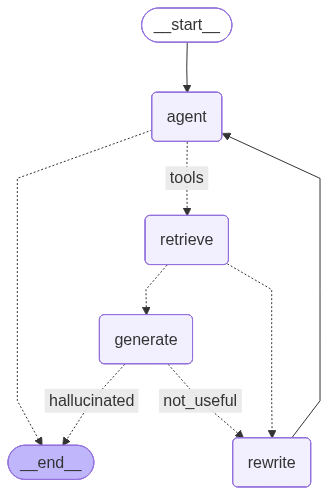

In [36]:
# FIX #32: All nodes defined above — safe to compile now.
# FIX #17: recursion_limit set dynamically at invoke time; compile-time default is generous.
# FIX #18/#19/#20: hallucinated → END (not rewrite).

def build_rag_graph(checkpointer=None):
    """Build and compile the Agentic RAG StateGraph."""
    workflow = StateGraph(AgentState)

    # Nodes
    workflow.add_node("agent",    agent_node)
    workflow.add_node("retrieve", ToolNode(retriever_tools, handle_tool_errors=True))
    workflow.add_node("rewrite",  rewrite_node)
    workflow.add_node("generate", generate_node)

    # Edges
    workflow.add_edge(START, "agent")

    workflow.add_conditional_edges(
        "agent",
        tools_condition,
        {"tools": "retrieve", END: END},
    )

    workflow.add_conditional_edges(
        "retrieve",
        grade_documents_node,
        {"generate": "generate", "rewrite": "rewrite"},
    )

    workflow.add_edge("rewrite", "agent")

    # FIX #18/#19/#20: 'hallucinated' terminates at END; 'not_useful' rerenders via rewrite
    # but rewrite_node hard-stops when budget is exhausted
    workflow.add_conditional_edges(
        "generate",
        check_hallucination_node,
        {
            "useful":       END,
            "not_useful":   "rewrite",
            "hallucinated": END,   # accept imperfect answer rather than infinite loop
        },
    )

    return workflow.compile(checkpointer=checkpointer)


# Build in-memory graph (fast, no persistence)
_mem_checkpointer = MemorySaver()
rag_graph = build_rag_graph(checkpointer=_mem_checkpointer)

# Build persistent SQLite graph
_sqlite_conn   = sqlite3.connect(CONFIG["db_path"], check_same_thread=False)
persistent_rag = build_rag_graph(checkpointer=SqliteSaver(_sqlite_conn))

print(" Agentic RAG graph compiled (in-memory + SQLite persistent)")

try:
    display(Image(rag_graph.get_graph().draw_mermaid_png()))
except Exception:
    print("   (Graph image unavailable — install playwright/graphviz to render)")


##  12. Invocation Helpers — ask() and stream_ask()

In [37]:
def ask(
    question: str,
    *,
    graph=None,
    thread_id: str = "default",
    verbose: bool = True,
    show_trace: bool = False,
) -> str:
    """Ask the Agentic RAG agent a question and return the final answer."""
    if graph is None:
        graph = rag_graph

    # FIX #17: bounded recursion limit — generous but not infinite
    config: RunnableConfig = {
        "configurable": {"thread_id": thread_id},
        "recursion_limit": (CONFIG["max_rewrites"] + 1) * 6 + 10,
    }

    initial_state: AgentState = {
        "messages":           [HumanMessage(content=question)],
        "original_question":  question,
        "rewrite_count":      0,
        "retrieval_score":    "unknown",
        "retrieved_sources":  [],
        "hallucination_flag": False,
        "answer_grade":       "unknown",
        "node_history":       [],
        "error_count":        0,
        "session_id":         thread_id,
    }

    logger.info(f"▶ Question: {question!r} | thread={thread_id}")
    t0 = time.perf_counter()

    try:
        result = graph.invoke(initial_state, config=config)
    except Exception as exc:
        logger.error(f"Graph error: {exc}\n{traceback.format_exc()}")
        raise

    elapsed = time.perf_counter() - t0

    # FIX #44: skip error messages when picking final answer
    final_answer = next(
        (m.content for m in reversed(result["messages"])
         if isinstance(m, AIMessage) and m.content
         and not m.content.startswith("⚠️")),
        "No answer generated.",
    )

    if show_trace:
        history = result.get("node_history", [])
        print(f"\n  Node trace : {' → '.join(history)}")
        print(f"   Rewrites    : {result.get('rewrite_count', 0)}")
        print(f"   Errors      : {result.get('error_count', 0)}")

    if verbose:
        print("\n" + "═" * 70)
        print(f" {question}")
        print("─" * 70)
        print(final_answer)
        print("─" * 70)
        print(f"  {elapsed:.2f}s | thread={thread_id!r}")
        print("═" * 70)

    return final_answer


def stream_ask(question: str, *, thread_id: str = "stream_default") -> None:
    """Stream Agentic RAG response, printing each node's output as it arrives."""
    config: RunnableConfig = {
        "configurable": {"thread_id": thread_id},
        "recursion_limit": (CONFIG["max_rewrites"] + 1) * 6 + 10,
    }
    initial_state: AgentState = {
        "messages":           [HumanMessage(content=question)],
        "original_question":  question,
        "rewrite_count":      0,
        "retrieval_score":    "unknown",
        "retrieved_sources":  [],
        "hallucination_flag": False,
        "answer_grade":       "unknown",
        "node_history":       [],
        "error_count":        0,
        "session_id":         thread_id,
    }
    icons = {"agent": "🤖", "retrieve": "🔍", "rewrite": "✏️", "generate": "📝"}
    print(f" Streaming: {question!r}\n{'─'*60}")
    for event in rag_graph.stream(initial_state, config=config, stream_mode="updates"):
        for node_name, node_output in event.items():
            icon = icons.get(node_name, "⚙️")
            for msg in node_output.get("messages", []):
                content = str(msg.content or "")
                short   = content[:200].replace("\n", " ")
                if isinstance(msg, AIMessage) and content:
                    print(f"{icon} [{node_name}]: {short}…")
                elif isinstance(msg, ToolMessage):
                    print(f"🔧 [tool:{getattr(msg,'name','')}]: {short}…")
    print("─" * 60)


print(" Helpers ready: ask(), stream_ask()")


 Helpers ready: ask(), stream_ask()


## 13. Live Demos

In [38]:
# Demo 1 — LangChain runnables
ans1 = ask(
    "How do LangChain runnables and LCEL chains work?",
    thread_id="demo_1",
    show_trace=True,
)


    Relevance: YES — The context mentions LangChain, agents, and chains, which are relevant to the question about LangChain runnables and LCEL chains.
    Grounding: YES — The answer states that the provided context does not contain information about LangChain runnables and LCEL chains, which is supported by the source documents.

  Node trace : agent → generate
   Rewrites    : 0
   Errors      : 0

══════════════════════════════════════════════════════════════════════
 How do LangChain runnables and LCEL chains work?
──────────────────────────────────────────────────────────────────────
### Insufficient Context
The provided context does not contain information about LangChain runnables and LCEL chains. It discusses the standard model interface, highly configurable harness, and the relationship with LangGraph, but does not mention runnables or LCEL chains.

## Sources
There are no URLs provided in the context metadata.
──────────────────────────────────────────────────────────────────

In [39]:
# Demo 2 — LangChain chatbot with history
ans2 = ask(
    "How do I build a conversational RAG chatbot with chat history in LangChain?",
    thread_id="demo_2",
    show_trace=True,
)


    Relevance: YES — The context is relevant because it discusses building a RAG agent with LangChain, which is directly related to the question about building a conversational RAG chatbot with chat history in LangChain.


ERROR:agentic_rag:Hallucination check error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kqp18gbbf42rp18gmmd8xgem` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99843, Requested 958. Please try again in 11m32.064s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}



  Node trace : agent → generate
   Rewrites    : 0
   Errors      : 0

══════════════════════════════════════════════════════════════════════
 How do I build a conversational RAG chatbot with chat history in LangChain?
──────────────────────────────────────────────────────────────────────
## Building a Conversational RAG Chatbot with Chat History in LangChain

Unfortunately, the provided context does not contain a step-by-step guide on building a conversational RAG chatbot with chat history in LangChain. However, it does introduce the concept of Retrieval Augmented Generation (RAG) and its application in building Q&A chatbots.

### Available Information

*   RAG is a technique used in building Q&A applications that can answer questions about specific source information.
*   LangChain is a library that supports building RAG agents.
*   LangSmith is a tool that allows you to inspect and log traces of your LangChain applications.

### Next Steps

To build a conversational RAG chatbot wit

In [40]:
# Demo 3 — Cross-domain (uses both tools when available)
ans3 = ask(
    "What is the difference between LangChain agents and LangGraph workflows?",
    thread_id="demo_3",
    show_trace=True,
)



  Node trace : agent
   Rewrites    : 0
   Errors      : 0

══════════════════════════════════════════════════════════════════════
 What is the difference between LangChain agents and LangGraph workflows?
──────────────────────────────────────────────────────────────────────
## Overview of LangChain Agents and LangGraph Workflows

To understand the difference between LangChain agents and LangGraph workflows, let's first look into each.

### LangChain Agents

LangChain agents are part of the LangChain framework, which is designed to help build applications powered by large language models (LLMs). Agents in LangChain are essentially wrappers around LLMs that provide a higher-level interface for interacting with these models. They can be used to perform a variety of tasks, such as:

* Answering questions
* Generating text
* Summarizing content
* And more

LangChain agents are typically used in chatbot construction, question-answering systems, and other applications where LLMs are used to

##  14. Streaming Demo

In [41]:
stream_ask(
    "Explain LangGraph state management with a code example.",
    thread_id="stream_demo",
)


 Streaming: 'Explain LangGraph state management with a code example.'
────────────────────────────────────────────────────────────


🤖 [agent]: ## LangGraph State Management LangGraph is a library for building stateful, multi-actor graphs. It provides a simple and efficient way to manage state across multiple nodes and edges in a graph.  ### …
────────────────────────────────────────────────────────────


##  15. Inspect Thread State

In [42]:
def inspect_rag_thread(thread_id: str, graph=None) -> None:
    if graph is None:
        graph = rag_graph
    config = {"configurable": {"thread_id": thread_id}}
    try:
        state = graph.get_state(config)
        vals  = state.values
        msgs  = vals.get("messages", [])
        print(f"\n Thread: {thread_id!r}  ({len(msgs)} messages)")
        print(f"   Node trace   : {' → '.join(vals.get('node_history', []))}")
        print(f"   Rewrite count: {vals.get('rewrite_count', 0)}")
        print(f"   Error count  : {vals.get('error_count', 0)}")
        print("─" * 60)
        for msg in msgs:
            role = type(msg).__name__.replace("Message", "")
            print(f"  [{role}] {str(msg.content)[:200].replace(chr(10),' ')}")
        print("─" * 60)
    except Exception as e:
        print(f"  Could not retrieve thread {thread_id!r}: {e}")


inspect_rag_thread("demo_1")



 Thread: 'demo_1'  (4 messages)
   Node trace   : agent → generate
   Rewrite count: 0
   Error count  : 0
────────────────────────────────────────────────────────────
  [Human] How do LangChain runnables and LCEL chains work?
  [AI] 
  [Tool] Standard model interfaceDifferent providers have unique APIs for interacting with models, including the format of responses. LangChain standardizes how you interact with models so that you can seamles
  [AI] ### Insufficient Context The provided context does not contain information about LangChain runnables and LCEL chains. It discusses the standard model interface, highly configurable harness, and the re
────────────────────────────────────────────────────────────


##  16. Vectorstore Diagnostics

In [43]:
def similarity_search_demo(query: str, source: str = "langchain", k: int = 3) -> None:
    if source not in vectorstores:
        print(f"Unknown source '{source}'. Available: {list(vectorstores.keys())}")
        return
    vs      = vectorstores[source]
    results = vs.similarity_search_with_relevance_scores(query, k=k)
    print(f"\n Top {k} for: {query!r}  (source={source})")
    print("─" * 60)
    for i, (doc, score) in enumerate(results, 1):
        print(f"  #{i} | Score: {score:.4f} | {doc.metadata.get('source','N/A')}")
        print(f"      {doc.page_content[:250].strip()}…")
    print("─" * 60)


# Run diagnostics for all available sources
for src in vectorstores:
    q = "retriever tutorial" if src == "langchain" else "node definition graph"
    similarity_search_demo(q, source=src)



 Top 3 for: 'node definition graph'  (source=langgraph)
────────────────────────────────────────────────────────────
  #1 | Score: 0.1039 | fallback_seed
      - Compile with workflow.compile(checkpointer=checkpointer).
- Invoke with graph.invoke(state, config={'configurable': {'thread_id': 'x'}}).
- graph.stream() yields node-by-node updates.
- get_state(config) retrieves thread snapshot.
- Multi-agent: us…
  #2 | Score: 0.0158 | fallback_seed
      LangGraph is a library for building stateful, multi-actor applications with LLMs using graph-based control flow. Core concepts:
- StateGraph: define a graph with a typed state schema.
- Nodes: Python functions or runnables that transform state.
- Edg…
────────────────────────────────────────────────────────────

 Top 3 for: 'retriever tutorial'  (source=langchain)
────────────────────────────────────────────────────────────
  #1 | Score: 0.2160 | https://python.langchain.com/docs/tutorials/chatbot/
      Integrations: 40+ integrations to 

##  17. Add Custom Documents

In [44]:
def add_documents(
    texts: List[str],
    source_tag: str,
    *,
    metadatas: Optional[List[Dict]] = None,
) -> None:
    if source_tag not in vectorstores:
        print(f"Unknown source '{source_tag}'. Available: {list(vectorstores.keys())}")
        return
    metadatas = metadatas or [
        {"source": "custom", "source_tag": source_tag}
    ] * len(texts)
    docs = [Document(page_content=t, metadata=m) for t, m in zip(texts, metadatas)]
    vectorstores[source_tag].add_documents(docs)
    print(f" Added {len(docs)} document(s) to '{source_tag}' vectorstore")


# Add to langgraph source if available, otherwise langchain
_target = "langgraph" if "langgraph" in vectorstores else "langchain"
add_documents(
    texts=[
        "LangGraph interrupt() pauses graph execution for human input. "
        "Use interrupt_before=['node_name'] in compile() for human-in-the-loop workflows. "
        "After human input is received, call graph.update_state() and resume."
    ],
    source_tag=_target,
    metadatas=[{"source": "custom_knowledge", "topic": "human_in_the_loop"}],
)


 Added 1 document(s) to 'langgraph' vectorstore


##  18. System Summary

In [45]:
def system_summary() -> None:
    print("\n" + "═" * 60)
    print("  Agentic RAG — System Summary")
    print("═" * 60)
    print(f"  LLM primary    : {CONFIG['model']}")
    print(f"  LLM fallback   : {CONFIG['fallback_model']}")
    print(f"  Embedding model: {CONFIG['embedding_model']}")
    print(f"  Chunk size     : {CONFIG['chunk_size']} / overlap {CONFIG['chunk_overlap']}")
    print(f"  Top-K (MMR)    : {CONFIG['top_k']}")
    print(f"  Max rewrites   : {CONFIG['max_rewrites']}")
    print(f"  Persistent DB  : {CONFIG['db_path']}")
    print(f"  Vectorstore dir: {CONFIG['vectorstore_dir']}/")
    print(f"  Retry base delay: {CONFIG['retry_base_delay']}s (exponential)")
    print()
    for name, vs in vectorstores.items():
        n = getattr(vs.index, "ntotal", "?")
        print(f"  [{name}] vectors: {n}")
    print()
    print(f"  Retriever tools: {[t.name for t in retriever_tools]}")
    print("═" * 60)
    print("   System operational")
    print("═" * 60)


system_summary()



════════════════════════════════════════════════════════════
  Agentic RAG — System Summary
════════════════════════════════════════════════════════════
  LLM primary    : llama-3.3-70b-versatile
  LLM fallback   : meta-llama/llama-4-scout-17b-16e-instruct
  Embedding model: all-MiniLM-L6-v2
  Chunk size     : 800 / overlap 150
  Top-K (MMR)    : 3
  Max rewrites   : 2
  Persistent DB  : agentic_rag_memory.db
  Vectorstore dir: vectorstore_cache/
  Retry base delay: 2.0s (exponential)

  [langgraph] vectors: 3
  [langchain] vectors: 68

  Retriever tools: ['search_langgraph_docs', 'search_langchain_docs']
════════════════════════════════════════════════════════════
   System operational
════════════════════════════════════════════════════════════
